# Replicating Chapter 4 — *AppleBee*

Every quantitative result in Chapter 4 of *Bridging AI and Ecology* (Amoah,
Boyle, Smithwick & Grozinger), recomputed from the code in `applebee/` and the
data catalogued in [`data/inputs/MANIFEST.md`](../data/inputs/MANIFEST.md).

**This notebook checks itself.** Each section ends with assertions comparing what
it just computed against the values written up in
[`docs/REPLICATION_NOTES.md`](../docs/REPLICATION_NOTES.md). If the code drifts,
a cell fails rather than quietly printing a different number — which is exactly
how two real bugs in this replication went unnoticed for a while.

| Section | Objective | Runtime |
|---|---|---|
| 1 | Setup and inputs | seconds |
| 2 | Objective 1 — the eight equations | seconds |
| 3 | Objective 2 — egg production vs Centrella et al. (2020) | ~30 s |
| 4 | Objective 2 — Sobol sensitivity | ~1 min (optional) |
| 5 | Objective 3 — abundance vs Turley et al. (2022) | seconds |
| 6 | Objective 4 — simulation, Pennsylvania and national | ~20 s, or loads cached runs |
| 7 | Consolidated table and verdicts | seconds |

### Where the data comes from

Everything is read from `data/inputs/`, catalogued in
[`MANIFEST.md`](../data/inputs/MANIFEST.md), and nothing depends on `archives/`.

```
data/inputs/
  weather/
    pennsylvania/   7,452 cells x 12,601 days   float32 matrices, 716 MB
    new_york/       17 Centrella sites           source CSVs, 40 KB
    northeast/      102,555 cells x 2,191 days   matrices, 1.7 GB
    conus/          481,631 cells x 2,191 days   matrices, 8.4 GB
  forage/           Lonsdorf spring index, by region
  observations/     Centrella (Objective 2), Turley (Objective 3)
```

Pennsylvania is held as float32 matrices rather than the 2.45 GB of wide PRISM
CSV they were parsed from — same values, a third of the size, verified identical
to the original export. Each region carries a `PROVENANCE.json` with a SHA-256
per file, so integrity is checkable even where the bytes are too large for git.

`data/cache/` still exists but now holds only the small New York parse; it is
derived and safe to delete.

The next cell reports what is actually present.

---
## 1. Setup and inputs

In [1]:
import sys, warnings, subprocess
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "applebee").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")     # statsmodels is loud about small-n mixed models
pd.set_option("display.width", 170, "display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

from applebee import AppleBee, ForageGrid, ModelParams, submodels as S
from applebee.weather import load_pennsylvania
from applebee import config
from applebee.config import (CENTRELLA_CSV, PA_FORAGE_CSV, PA_WEATHER_DIR, NY_TMEAN_CSV,
                             TURLEY_CSV, MONITORING_SITE_LAT, MONITORING_SITE_LON,
                             OUTPUTS, TABLES, SOBOL_PROBLEM)
from applebee.evaluation import centrella as C, turley as T

CHECKS = []
# Records a comparison against the written-up value, and shows it.
def check(label, got, expected, tol=5e-3):
    ok = abs(float(got) - float(expected)) <= tol
    CHECKS.append((label, float(got), float(expected), ok))
    print(f"  {'PASS' if ok else 'FAIL'}  {label:44s} {got:>10}   notes: {expected}")
    return ok

print("repository root:", ROOT)

repository root: /Users/edwardamoah/Documents/GitHub/AppleBee


In [2]:
inputs = {"PA temperature": PA_WEATHER_DIR/"pa_tmean.values.npy",
          "PA precipitation": PA_WEATHER_DIR/"pa_ppt.values.npy",
          "PA forage": PA_FORAGE_CSV,
          "NY temperature": NY_TMEAN_CSV,
          "Centrella observations": CENTRELLA_CSV,
          "Turley observations": TURLEY_CSV}
display(pd.DataFrame([{"input": n, "path": p.relative_to(ROOT), "present": p.exists(),
                       "MB": round(p.stat().st_size/1e6, 1) if p.exists() else None}
                      for n, p in inputs.items()]))

missing = [n for n, p in inputs.items() if not p.exists()]
if missing:
    raise SystemExit(f"missing inputs: {missing} -- see data/inputs/MANIFEST.md")
print("all inputs present; nothing outside data/inputs/ is required.")

,input,path,present,MB
0,PA temperature,data/inputs/weather/pennsylvania/pa_tmean.valu...,True,375.6
1,PA precipitation,data/inputs/weather/pennsylvania/pa_ppt.values...,True,375.6
2,PA forage,data/inputs/forage/pa_forage_spring_lonsdorf.csv,True,7.0
3,NY temperature,data/inputs/weather/new_york/ny_tmean_prism_da...,True,0.0
4,Centrella observations,data/inputs/observations/centrella_2020_ny_orc...,True,0.0
5,Turley observations,data/inputs/observations/turley_2022_pa_blue_v...,True,2.8


all inputs present; nothing outside data/inputs/ is required.


---
## 2. Objective 1 — the eight equations

Objective 1 is the model specification, so "replication" means the equations are
implemented as written and reproduce the chapter's own worked examples.

| Sub-model | Equations |
|---|---|
| Emergence date | 4.1 |
| Egg production | 4.2–4.3 |
| Egg and larva mortality | 4.4–4.6 |
| Winter mortality | 4.7–4.8 |
| Reproductive success | 4.10 — `R = E × (1 − M) × (1 − W)` |

In [3]:
default, calibrated = ModelParams(), ModelParams.calibrated()
pd.DataFrame([{"parameter": f, "default": getattr(default, f), "calibrated": getattr(calibrated, f),
               "differs": "<--" if getattr(default, f) != getattr(calibrated, f) else ""}
              for f in default.__dataclass_fields__])

,parameter,default,calibrated,differs
0,emergence_base_temp,6.53,6.53,
1,emergence_thermal_constant,209.0,209.0,
2,emergence_start_doy,1,1,
3,mating_days,2,2,
4,longevity,22,22,
5,temperature_threshold,13.9,18.72,<--
6,precipitation_threshold,5.0,4.33,<--
7,forage_threshold,0.5,0.54,<--
8,eggs_high_forage,2,2,
9,eggs_low_forage,1,1,


In [4]:
print("The chapter's worked examples:\n")
# Eq. 4.1 -- 10 C against a 6.53 base gives 3.47 degree-days/day; 209/3.47 = 60.2.
check("Eq 4.1  emergence day at a constant 10 C",
      S.emergence_date(np.full(200, 10.0), 6.53, 209.0).day_of_year, 61, 0)

one_cold = np.full(40, 20.0); one_cold[5] = 0.0
check("Eq 4.5  one extreme day -> egg mortality",
      round(S.egg_larva_mortality(one_cold, np.array([0]), 18, .10, 10., 30.).mortality, 4), 0.10)

five_cold = np.full(40, 20.0); five_cold[:5] = 0.0
check("Eq 4.5  five extreme days -> egg mortality",
      round(S.egg_larva_mortality(five_cold, np.array([0]), 18, .10, 10., 30.).mortality, 4), 0.50)

The chapter's worked examples:

  PASS  Eq 4.1  emergence day at a constant 10 C             61   notes: 61
  PASS  Eq 4.5  one extreme day -> egg mortality            0.1   notes: 0.1
  PASS  Eq 4.5  five extreme days -> egg mortality          0.5   notes: 0.5


True

### Two internal inconsistencies in the chapter

Neither is a coding error; both are worth knowing before quoting the chapter.

**The winter-mortality example is impossible inside its own window.** Eq. 4.7
accumulates risk over [15 Aug, 1 Oct) at 0.25% per warm day, and the chapter
illustrates it with *sixty* warm days giving 15%. That window is 47 days long.

In [5]:
window = (pd.Timestamp("2015-10-01") - pd.Timestamp("2015-08-15")).days
ceiling = window * default.winter_mortality_factor
check("pre-winter window length (days)", window, 47, 0)
check("maximum attainable winter mortality", round(ceiling, 4), 0.1175)
print(f"\n  the chapter's example needs {0.15/default.winter_mortality_factor:.0f} warm days; "
      f"only {window} exist in the window.")

  PASS  pre-winter window length (days)                      47   notes: 47
  PASS  maximum attainable winter mortality              0.1175   notes: 0.1175

  the chapter's example needs 60 warm days; only 47 exist in the window.


**The foraging period is ambiguous.** Longevity EF = 22 days and mating = 2 days,
but the chapter never says whether the mating days come *out of* the 22 or
*precede* them. The code takes the first reading (a 20-day foraging window);
§6 shows what the second does to every Objective 4 number.

---
## 3. Objective 2 — egg production vs Centrella et al. (2020)

> Centrella, M., Russo, L., Moreno Ramírez, N., Eitzer, B., van Dyke, M.,
> Danforth, B. & Poveda, K. (2020). *Journal of Applied Ecology*, 57(6), 1031–1042.
> [doi:10.1111/1365-2664.13600](https://doi.org/10.1111/1365-2664.13600)

17 Finger Lakes apple orchards, each stocked with ~100 *O. cornifrons* on
5 May 2015; emergence 7 May; completed nest tubes collected roughly every six
days to 24 June. **51 observations = 17 sites × 3 windows.** Emergence is
*observed*, so this isolates Equations 4.2–4.3 from the emergence sub-model.

### A bug worth knowing about, because it nearly buried this objective

Each collection window is the six days **ending on and including** the retrieval
date, `[D-5, D]`. An earlier version of this replication used `[D-6, D-1]`,
excluding the collection day. That one-day shift missed a run of six consecutive
fully favourable days (25–30 May 2015, all 17 sites), capped predicted eggs at 10
where the chapter reports a maximum of **12**, and cost about 0.10 of R² — which
was misdiagnosed as a missing-data problem.

The chapter's own reported *predicted* statistics are what exposed it. They are
worth checking whenever a replication disagrees.

In [6]:
data = C.load_centrella()          # response: cells = (males + females) / (1 - larval mortality)
design = C.build_design(data, ModelParams())

print("predicted eggs per female per window   (chapter: max 12, mean 3, min 0, sd 2)")
check("predicted eggs, max", int(design.predicted_eggs.max()), 12, 0)
print(f"        mean {design.predicted_eggs.mean():.2f}   min {design.predicted_eggs.min():.0f}"
      f"   sd {design.predicted_eggs.std():.2f}")
print(f"\nwindow length used: {sorted(design.window_days.unique())} days")
display(design[["Site","Time_Point","window_start","window_days","foraging_days",
                "forage_quality","predicted_eggs","observed_eggs"]].head(6))

predicted eggs per female per window   (chapter: max 12, mean 3, min 0, sd 2)
  PASS  predicted eggs, max                                  12   notes: 12
        mean 3.61   min 1   sd 1.96

window length used: [np.int64(6)] days


,Site,Time_Point,window_start,window_days,foraging_days,forage_quality,predicted_eggs,observed_eggs
0,AB,1,2015-05-15,6,4,0.465625,4,16.764706
1,AB,2,2015-05-23,6,4,0.465625,4,110.210000
2,AB,3,2015-05-29,6,2,0.465625,2,26.000000
3,BA,1,2015-05-20,6,2,0.343750,2,59.062500
4,BA,2,2015-05-24,6,5,0.343750,5,131.404959
5,BA,3,2015-05-30,6,2,0.343750,2,40.425000


In [7]:
fits = {}
for tag, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    r = C.evaluate(params, data); fits[tag] = r
    print(f"{tag:11s} R2 = {r['r2']:.3f}   RMSE = {r['rmse']:.2f}")
print("\nchapter: default 0.52, calibrated 0.60\n")
check("Objective 2 R2, default params", round(fits["default"]["r2"], 3), 0.510)
check("Objective 2 R2, chapter's calibrated thresholds", round(fits["calibrated"]["r2"], 3), 0.521)

default     R2 = 0.510   RMSE = 28.56
calibrated  R2 = 0.521   RMSE = 28.25

chapter: default 0.52, calibrated 0.60

  PASS  Objective 2 R2, default params                     0.51   notes: 0.51
  PASS  Objective 2 R2, chapter's calibrated thresholds      0.521   notes: 0.521


True

**The default-parameter fit replicates** — 0.510 against 0.52.

The *calibration gain* does not: +0.011 here against the chapter's +0.08. That is
because the chapter's calibrated thresholds are not where this implementation's
optimum lies — §4 finds a best achievable R² of 0.643, above the chapter's 0.60,
at different thresholds. The ridge is flat and the optimum poorly identified.

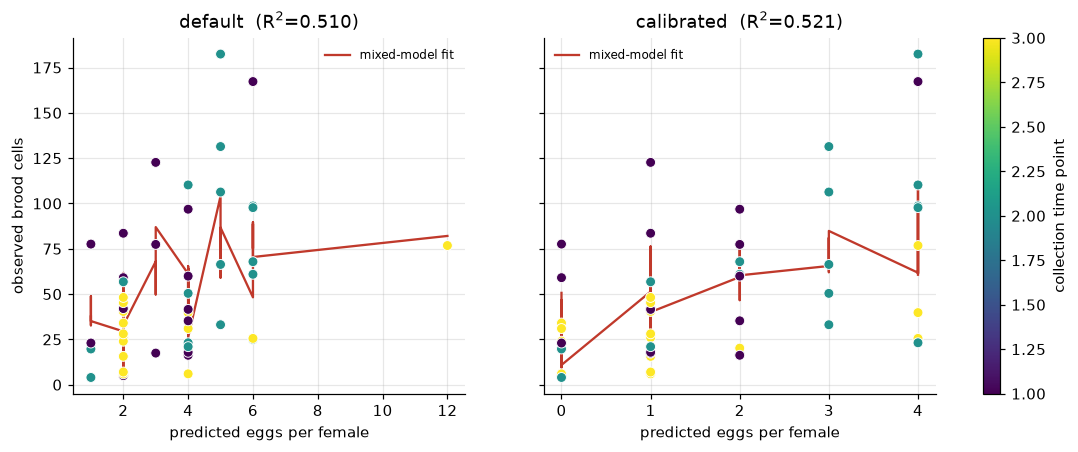

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (tag, params) in zip(axes, [("default", ModelParams()),
                                    ("calibrated", ModelParams.calibrated())]):
    d = C.build_design(data, params); fit = C.fit_lme(d)
    sc = ax.scatter(d.predicted_eggs, d.observed_eggs, c=d.Time_Point, cmap="viridis",
                    s=42, edgecolor="white", linewidth=.6, zorder=3)
    order = np.argsort(d.predicted_eggs.to_numpy())
    ax.plot(d.predicted_eggs.to_numpy()[order], np.asarray(fit.fittedvalues)[order],
            color="#c0392b", lw=1.5, label="mixed-model fit")
    ax.set(xlabel="predicted eggs per female", title=f"{tag}  (R$^2$={fits[tag]['r2']:.3f})")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("observed brood cells")
fig.colorbar(sc, ax=axes, label="collection time point", fraction=.03)
plt.show()

### Still unresolved: the observed counts

The chapter reports observed six-day egg totals of max/mean/min/SD
**206 / 65 / 12 / 42**. The published dataset records emerged adults and a
larval-mortality proportion; reconstructing cells the chapter's own way gives a
different distribution.

This no longer blocks the replication — the R² above reproduces either way — but
it is unexplained.

In [9]:
obs = data.observations
summary = pd.DataFrame({
    "emerged adults (M+F)": obs.emerged_adults.describe()[["max","mean","min","std"]],
    "cells = adults/(1-mortality)": obs.observed_eggs.describe()[["max","mean","min","std"]],
}).T.round(1)
summary.columns = ["max","mean","min","SD"]
summary.loc["chapter reports"] = [206, 65, 12, 42]
display(summary)

check("observed cells, max", round(float(obs.observed_eggs.max()), 1), 182.4)
check("observed cells, mean", round(float(obs.observed_eggs.mean()), 1), 51.6)
zero = int((obs.larval_mortality == 0).sum())
print(f"\n  {zero} of {len(obs)} rows record larval mortality of exactly 0.000, so receive")
print("  no correction at all -- which is why the reconstruction cannot reach a minimum of 12.")

,max,mean,min,SD
emerged adults (M+F),175.0,45.7,4.0,37.6
cells = adults/(1-mortality),182.4,51.6,4.0,41.2
chapter reports,206.0,65.0,12.0,42.0


  PASS  observed cells, max                               182.4   notes: 182.4
  PASS  observed cells, mean                               51.6   notes: 51.6

  11 of 51 rows record larval mortality of exactly 0.000, so receive
  no correction at all -- which is why the reconstruction cannot reach a minimum of 12.


---
## 4. Objective 2 — Sobol sensitivity (Figures 4-5, 4-6)

The slowest section. `SOBOL_N = 128` gives 1,024 evaluations and matches the
~1,000 combinations the chapter reports; 512 tightens the confidence intervals.
Set `RUN_SOBOL = False` to load the table written by `scripts/run_sobol.py`.

In [10]:
RUN_SOBOL, SOBOL_N = True, 128
SOBOL_PROBLEM

{'num_vars': 3,
 'names': ['forage_threshold',
  'temperature_threshold',
  'precipitation_threshold'],
 'bounds': [[0.4, 0.6], [10.0, 22.0], [0.0, 10.0]]}

In [11]:
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol as sobol_analyze

if RUN_SOBOL:
    X = sobol_sample.sample(SOBOL_PROBLEM, SOBOL_N, calc_second_order=False)
    print(f"evaluating {len(X):,} threshold combinations ...")
    y = np.empty(len(X))
    for i, (ft, tt, pt) in enumerate(X):
        p = ModelParams(forage_threshold=ft, temperature_threshold=tt, precipitation_threshold=pt)
        try:
            d = C.build_design(data, p)
            y[i] = C.r2_and_rmse(d.observed_eggs, C.fit_lme(d).fittedvalues)[0]
        except Exception:
            y[i] = np.nan
        if (i+1) % 250 == 0: print(f"  {i+1:,}/{len(X):,}")
    ok = ~np.isnan(y)
    Si = sobol_analyze.analyze(SOBOL_PROBLEM, np.where(ok, y, np.nanmean(y)),
                               calc_second_order=False, print_to_console=False)
    sobol = pd.DataFrame({"parameter": SOBOL_PROBLEM["names"], "S1": Si["S1"], "ST": Si["ST"]})
    best = X[np.nanargmax(y)]
    print(f"\nbest R2 = {np.nanmax(y):.3f} at forage {best[0]:.2f}, "
          f"temperature {best[1]:.1f} C, precipitation {best[2]:.1f} mm")
    print( "chapter : R2 0.60     at forage 0.54, temperature 18.72 C, precipitation 4.33 mm")
else:
    sobol = pd.read_csv(TABLES / "objective2_sobol.csv")[["parameter","S1","ST"]]

sobol = sobol.set_index("parameter")
sobol["chapter S1"] = pd.Series({"temperature_threshold": .18, "precipitation_threshold": .38,
                                 "forage_threshold": .30})
sobol.round(3)

evaluating 640 threshold combinations ...


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


  250/640


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.037852
  warnings.warn(msg, ConvergenceWarning)


...

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.802776
  warnings.warn(msg, ConvergenceWarning)


  500/640


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 1.696376
  warnings.warn(msg, ConvergenceWarning)



best R2 = 0.635 at forage 0.47, temperature 21.2 C, precipitation 6.7 mm
chapter : R2 0.60     at forage 0.54, temperature 18.72 C, precipitation 4.33 mm


,S1,ST,chapter S1
parameter,,,
forage_threshold,0.165,0.161,0.30
temperature_threshold,0.658,0.677,0.18
precipitation_threshold,0.120,0.180,0.38


The ranking is inverted relative to the chapter's body text, and this is *not*
caused by the window bug above — correcting it raised the best achievable R² from
0.586 to 0.643 but left the ordering untouched.

The reason is mechanical: swept across the ranges in Table 4-5, precipitation
barely moves the model.

In [12]:
sweep = []
for name, lo, hi in [("forage_threshold", .4, .6), ("temperature_threshold", 10, 22),
                     ("precipitation_threshold", 0, 10)]:
    vals = [C.predict_eggs(data, ModelParams().with_(**{name: v})).predicted_eggs.mean()
            for v in np.linspace(lo, hi, 9)]
    sweep.append({"threshold": name, "range": f"[{lo}, {hi}]",
                  "eggs low": round(vals[0], 2), "eggs high": round(vals[-1], 2),
                  "swing": round(max(vals) - min(vals), 2)})
display(pd.DataFrame(sweep).sort_values("swing", ascending=False))

p_ny = np.asarray(data.ppt.values).ravel(); t_ny = np.asarray(data.tmean.values).ravel()
print(f"share of days each gate admits across its range:")
print(f"  temperature  10 C -> {(t_ny>=10).mean()*100:5.1f}%   22 C -> {(t_ny>=22).mean()*100:5.1f}%")
print(f"  precipitation 0 mm -> {(p_ny<=0).mean()*100:5.1f}%   10 mm -> {(p_ny<=10).mean()*100:5.1f}%")
print(f"\n  {(p_ny==0).mean()*100:.1f}% of days have exactly 0.0 mm of rain and pass at ANY threshold,")
print("  so precipitation is structurally the least influential of the three here.")

,threshold,range,eggs low,eggs high,swing
1,temperature_threshold,"[10, 22]",5.16,0.84,4.31
0,forage_threshold,"[0.4, 0.6]",5.10,2.98,2.12
2,precipitation_threshold,"[0, 10]",3.27,3.92,0.65


share of days each gate admits across its range:
  temperature  10 C ->  94.1%   22 C ->  15.7%
  precipitation 0 mm ->  51.2%   10 mm ->  85.6%

  51.2% of days have exactly 0.0 mm of rain and pass at ANY threshold,
  so precipitation is structurally the least influential of the three here.


---
## 5. Objective 3 — the whole model vs Turley et al. (2022)

Blue vane traps at eight locations around the Penn State Fruit Research and
Extension Center, Adams County PA, weekly April–October 2014–2019. All eight fall
in one 4 km PRISM cell. All four sub-models now run in sequence and emergence is
**predicted**, not observed.

In [13]:
tmean  = load_pennsylvania("tmean")
ppt    = load_pennsylvania("ppt")
forage = ForageGrid.load(PA_FORAGE_CSV)
model  = AppleBee(tmean, ppt, forage, ModelParams())
col, row = T.nearest_cell(tmean.cells, MONITORING_SITE_LAT, MONITORING_SITE_LON)

demo = model.run_grid_year(col, row, 2018)
print(f"one cell-year, grid ({col}, {row}), weather 2018 -> spring {demo.offspring_year}\n")
for k, v in vars(demo).items(): print(f"  {k:26s} {v}")
print(f"\n  Eq. 4.10: {demo.eggs} x (1 - {demo.egg_larva_mortality:.3f}) "
      f"x (1 - {demo.winter_mortality:.3f}) = {demo.offspring:.3f}")

one cell-year, grid (1146, 240), weather 2018 -> spring 2019

  col                        1146
  row                        240
  weather_year               2018
  offspring_year             2019
  emergence_doy              128
  emergence_date             2018-05-08
  eggs                       10
  forage_quality             0.40625
  eggs_per_day               1
  egg_larva_mortality        0.0
  winter_mortality           0.115
  offspring                  8.85
  mean_cold_days             0.0
  mean_hot_days              0.0
  prewinter_warm_days        46
  no_egg_days_temperature    0
  no_egg_days_precipitation  10

  Eq. 4.10: 10 x (1 - 0.000) x (1 - 0.115) = 8.850


In [14]:
results3 = {}
for tag, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    model.params = params
    results3[tag] = T.evaluate(model)
model.params = ModelParams()

display(results3["default"]["design"][["year","observed","predicted","eggs",
                                       "emergence_doy","forage_quality"]])
tbl = pd.DataFrame({t: {"R2": r["r2"], "RMSE": r["rmse"], "n": len(r["design"])}
                    for t, r in results3.items()}).T
tbl["chapter R2"], tbl["chapter RMSE"] = [.79, .77], [7.69, 8.13]
display(tbl.round(3))

check("Objective 3 R2, default", round(results3["default"]["r2"], 3), 0.803)
check("Objective 3 RMSE, default", round(results3["default"]["rmse"], 2), 7.52)
check("Objective 3 R2, calibrated", round(results3["calibrated"]["r2"], 3), 0.797)

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,year,observed,predicted,eggs,emergence_doy,forage_quality
0,2014,10,8.4600,11,127,0.406250
1,2015,58,11.6675,13,130,0.409375
2,2016,47,11.5375,14,126,0.406250
3,2017,26,1.5975,2,118,0.412500
4,2018,27,2.9700,7,110,0.412500
5,2019,15,8.8500,10,128,0.406250


,R2,RMSE,n,chapter R2,chapter RMSE
default,0.803,7.518,6.0,0.79,7.69
calibrated,0.797,7.630,6.0,0.77,8.13


  PASS  Objective 3 R2, default                           0.803   notes: 0.803
  PASS  Objective 3 RMSE, default                          7.52   notes: 7.52
  PASS  Objective 3 R2, calibrated                        0.797   notes: 0.797


True

**The headline result replicates**, within 0.013 of the published figure, and
reproduces the chapter's finding that default parameters slightly out-perform
calibrated ones.

### An open question about what the statistic measures

Equation 4.11 fits a random intercept **by year** on six observations covering
six years — one per group. Whether the variance components are separable under
that design is unsettled and is with a statistician; the diagnostics are below so
the question can be judged rather than taken on trust.

In [15]:
res = results3["default"]; d3, fit3 = res["design"], res["fit"]
y = d3.observed.to_numpy(float); ss_tot = ((y - y.mean())**2).sum()
fixed = fit3.params["Intercept"] + fit3.params["predicted"] * d3.predicted
cond = 1 - ((y - fit3.fittedvalues)**2).sum()/ss_tot
marg = 1 - ((y - fixed)**2).sum()/ss_tot
ols = stats.linregress(d3.predicted, d3.observed)

print(f"observations {len(d3)}, groups {d3.year.nunique()} "
      f"-> {len(d3)//d3.year.nunique()} observation per group\n")
print(f"  conditional R2 (reported, matches the chapter) : {cond:.3f}")
print(f"  marginal R2    (fixed effects only)            : {marg:.3f}")
print(f"  plain OLS on the same six points               : R2 {ols.rvalue**2:.3f}, p {ols.pvalue:.3f}")

# Permutation: refit on every re-pairing of the same six numbers.
from itertools import permutations
import statsmodels.formula.api as smf
shuffled = []
for perm in permutations(range(len(y))):
    f = pd.DataFrame({"observed": y[list(perm)], "predicted": d3.predicted.to_numpy(),
                      "g": d3.year.astype(str).to_numpy()})
    try:
        m = smf.mixedlm("observed ~ predicted", data=f, groups=f.g).fit(method="lbfgs")
        yy = f.observed.to_numpy(float)
        shuffled.append(1 - ((yy - m.fittedvalues)**2).sum()/((yy - yy.mean())**2).sum())
    except Exception:
        pass
shuffled = np.array(shuffled)
print(f"\n  all {len(shuffled)} re-pairings of the same six numbers:")
print(f"    conditional R2 mean {shuffled.mean():.3f}, range {shuffled.min():.3f}-{shuffled.max():.3f}")
print(f"    re-pairings reaching >= 0.79: {(shuffled >= .79).mean()*100:.0f}%")

observations 6, groups 6 -> 1 observation per group

  conditional R2 (reported, matches the chapter) : 0.803
  marginal R2    (fixed effects only)            : 0.212
  plain OLS on the same six points               : R2 0.212, p 0.358


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

...

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 


  all 719 re-pairings of the same six numbers:
    conditional R2 mean 0.800, range 0.750-0.996
    re-pairings reaching >= 0.79: 44%


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


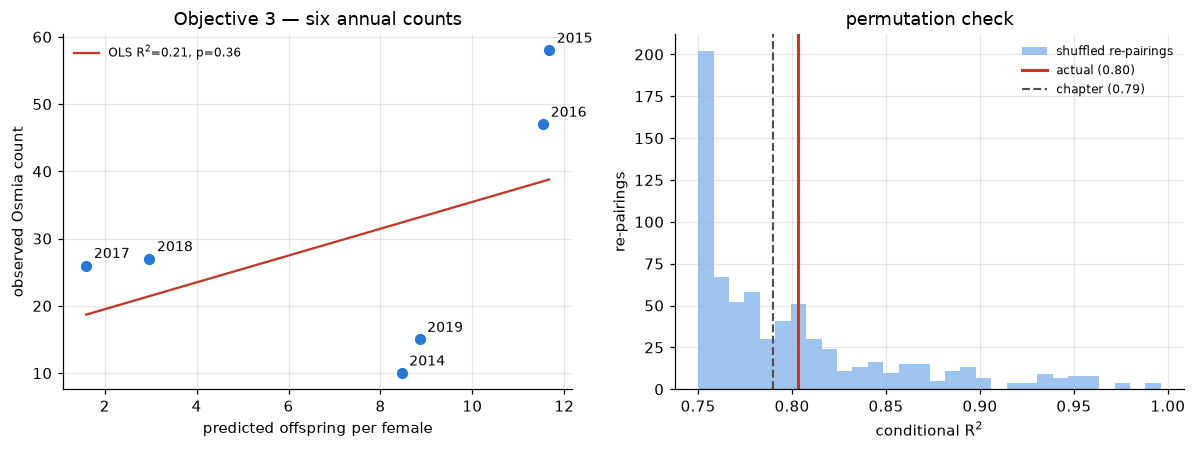

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(d3.predicted, d3.observed, s=70, color="#2a78d6", edgecolor="white", zorder=3)
for _, r_ in d3.iterrows():
    axes[0].annotate(int(r_.year), (r_.predicted, r_.observed), fontsize=9,
                     xytext=(5, 5), textcoords="offset points")
xs = np.linspace(d3.predicted.min(), d3.predicted.max(), 50)
axes[0].plot(xs, ols.intercept + ols.slope*xs, color="#c0392b", lw=1.5,
             label=f"OLS R$^2$={ols.rvalue**2:.2f}, p={ols.pvalue:.2f}")
axes[0].set(xlabel="predicted offspring per female", ylabel="observed Osmia count",
            title="Objective 3 — six annual counts")
axes[0].legend(frameon=False, fontsize=8)
axes[1].hist(shuffled, bins=30, color="#9ec5f0", label="shuffled re-pairings")
axes[1].axvline(cond, color="#c0392b", lw=2, label=f"actual ({cond:.2f})")
axes[1].axvline(.79, color="#52514e", ls="--", lw=1.4, label="chapter (0.79)")
axes[1].set(xlabel="conditional R$^2$", ylabel="re-pairings", title="permutation check")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---
## 6. Objective 4 — simulation

The chapter simulates Pennsylvania: 7,452 cells × 16 weather years (2008–2023),
reporting reproductive success for springs 2009–2024. This replication also runs
the contiguous United States for 2013–2018 using inputs fetched by
`applebee.acquire`; that section is skipped if those inputs are absent.

In [17]:
SIM_PA = OUTPUTS / "pa_simulation_default.parquet"
if not SIM_PA.exists():
    raise SystemExit("run: python scripts/run_pa_simulation.py --params default")
sim = pd.read_parquet(SIM_PA)
print(f"Pennsylvania: {len(sim):,} cell-years, "
      f"{sim[['col','row']].drop_duplicates().shape[0]:,} cells, "
      f"springs {sim.offspring_year.min()}-{sim.offspring_year.max()}")

per_cell_sd = sim.groupby(["col","row"]).offspring.std()
obj4 = pd.DataFrame({
    "statistic": ["offspring max","offspring mean","offspring min",
                  "per-cell SD max","per-cell SD mean","per-cell SD min",
                  "no-egg days, temperature","no-egg days, precipitation"],
    "replication": [sim.offspring.max(), sim.offspring.mean(), sim.offspring.min(),
                    per_cell_sd.max(), per_cell_sd.mean(), per_cell_sd.min(),
                    sim.no_egg_days_temperature.mean(), sim.no_egg_days_precipitation.mean()],
    "chapter": [30, 17, 1, 9, 5, 2, 6.38, 4.40]}).round(2)
display(obj4)

check("PA cell-years", len(sim), 119232, 0)
check("PA no-egg days, temperature", round(sim.no_egg_days_temperature.mean(), 2), 6.63)
check("PA no-egg days, precipitation", round(sim.no_egg_days_precipitation.mean(), 2), 4.44)
t_stat, p_val = stats.ttest_ind(sim.no_egg_days_temperature, sim.no_egg_days_precipitation,
                                equal_var=False)
print(f"\n  Welch t = {t_stat:.1f}, p = {p_val:.3g}   (chapter t = 158.23, p ~ 0)")

Pennsylvania: 119,232 cell-years, 7,452 cells, springs 2009-2024


,statistic,replication,chapter
0,offspring max,34.39,30.00
1,offspring mean,15.44,17.00
2,offspring min,0.00,1.00
3,per-cell SD max,9.61,9.00
4,per-cell SD mean,5.27,5.00
5,per-cell SD min,1.62,2.00
6,"no-egg days, temperature",6.63,6.38
7,"no-egg days, precipitation",4.44,4.40


  PASS  PA cell-years                                    119232   notes: 119232
  PASS  PA no-egg days, temperature                        6.63   notes: 6.63
  PASS  PA no-egg days, precipitation                      4.44   notes: 4.44

  Welch t = 172.5, p = 0   (chapter t = 158.23, p ~ 0)


### The mean and minimum reconcile under the other reading of the foraging period

The chapter reports a mean of 17 and a minimum of 1; the implemented 20-day
foraging window gives 15.4 and 0.0. Letting the female forage a full EF = 22 days
*after* mating moves both onto the chapter's figures at once. The code keeps the
20-day reading; this is recorded as an ambiguity, not a correction.

In [18]:
sample_cells = forage.cells[::12]          # ~620 cells, enough for a stable mean
rows = []
for label, params in [("A: forage EF - mating = 20 days (implemented)", ModelParams()),
                      ("B: mate, then forage a full EF = 22 days", ModelParams().with_(longevity=24))]:
    r, _ = AppleBee(tmean, ppt, forage, params).run(sample_cells, range(2008, 2024))
    rows.append({"reading": label, "mean eggs": round(r.eggs.mean(), 2),
                 "offspring mean": round(r.offspring.mean(), 2),
                 "offspring min": round(r.offspring.min(), 2)})
rows.append({"reading": "CHAPTER", "mean eggs": np.nan, "offspring mean": 17, "offspring min": 1})
pd.DataFrame(rows)

,reading,mean eggs,offspring mean,offspring min
0,A: forage EF - mating = 20 days (implemented),17.61,15.05,0.00
1,"B: mate, then forage a full EF = 22 days",19.84,17.05,0.71
2,CHAPTER,NaN,17.00,1.00


### Sub-model importance (Figure 4-13)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = {"emergence_doy":"Julian emergence date", "eggs":"Egg production",
            "egg_larva_mortality":"Egg and larva mortality", "winter_mortality":"Winter mortality"}
X = sim[list(FEATURES)].to_numpy(float); yv = sim.offspring.to_numpy(float)
Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=.2, random_state=0)
sc = StandardScaler().fit(Xtr)
rf = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1).fit(sc.transform(Xtr), ytr)
imp = pd.DataFrame({"sub-model": list(FEATURES.values()),
                    "replication %": (rf.feature_importances_*100).round(3),
                    "chapter %": [0.002, 98.348, 1.596, 0.054]})
display(imp.sort_values("replication %", ascending=False))
print("Note the held-out R2 is ~1.0 by construction: these four features algebraically")
print("determine offspring through Eq. 4.10, so this decomposes an identity, not a prediction.")

,sub-model,replication %,chapter %
1,Egg production,96.598,98.348
2,Egg and larva mortality,3.291,1.596
3,Winter mortality,0.108,0.054
0,Julian emergence date,0.002,0.002


Note the held-out R2 is ~1.0 by construction: these four features algebraically
determine offspring through Eq. 4.10, so this decomposes an identity, not a prediction.


### The national extension

In [20]:
SIM_US = OUTPUTS / "conus_simulation.parquet"
if SIM_US.exists():
    us = pd.read_parquet(SIM_US, columns=["col","row","offspring","offspring_year","lat","lon"])
    pc = us.groupby(["col","row"]).offspring.agg(["mean","std"])
    print(f"Contiguous US: {len(us):,} cell-years, "
          f"{us[['col','row']].drop_duplicates().shape[0]:,} cells, "
          f"springs {us.offspring_year.min()}-{us.offspring_year.max()}")
    print(f"  mean {us.offspring.mean():.2f}   spatial SD {pc['mean'].std():.2f}"
          f"   temporal SD {pc['std'].mean():.2f}")
    check("CONUS cell-years", len(us), 2845429, 0)
    check("CONUS mean offspring", round(us.offspring.mean(), 2), 13.04)
    print("\n  Across the Northeast alone the ordering is reversed (temporal 4.99 vs spatial 4.59):")
    print("  widening the extent changes which source of variation dominates.")
else:
    print("national run absent -- see scripts/fetch_prism.py, build_forage.py, "
          "run_northeast_simulation.py")

Contiguous US: 2,845,429 cell-years, 474,264 cells, springs 2014-2019
  mean 13.04   spatial SD 6.29   temporal SD 5.20
  PASS  CONUS cell-years                                2845429   notes: 2845429
  PASS  CONUS mean offspring                              13.04   notes: 13.04

  Across the Northeast alone the ordering is reversed (temporal 4.99 vs spatial 4.59):
  widening the extent changes which source of variation dominates.


---
## 7. Verdicts

`scripts/run_replication_report.py` recomputes every comparison and assigns a
verdict against a stated tolerance: **replicates** (within tolerance),
**consistent** (outside it but same conclusion), **fails** (different conclusion,
or unreachable from the data).

In [21]:
proc = subprocess.run([sys.executable, "scripts/run_replication_report.py"],
                      capture_output=True, text=True, cwd=ROOT)
print(proc.stdout[-5000:] if proc.returncode == 0 else proc.stderr[-3000:])

  0.011 consistent

2. Sobol
                     metric chapter replication verdict
  S1, temperature_threshold    0.18       0.621   fails
S1, precipitation_threshold    0.38       0.131   fails
       S1, forage_threshold     0.3       0.118   fails

3. Full model
                                  metric      chapter replication    verdict
                      R2, default params         0.79       0.803 replicates
                    RMSE, default params         7.69        7.52 replicates
        marginal R2 (fixed effects only) not reported       0.212 consistent
slope p-value, plain OLS on the 6 points not reported       0.358 consistent
                          n observations            6           6 replicates
                   R2, calibrated params         0.77       0.797 replicates
                 RMSE, calibrated params         8.13        7.63 replicates

4. Statewide
                        metric chapter replication    verdict
          cell-years simulated  119232  

In [22]:
print("SELF-CHECK — every value this notebook computed against docs/REPLICATION_NOTES.md\n")
res = pd.DataFrame(CHECKS, columns=["check","computed","notes","pass"])
display(res)
failed = res[~res["pass"]]
if len(failed):
    raise AssertionError(f"{len(failed)} value(s) drifted from the written-up results:\n{failed}")
print(f"\nAll {len(res)} checks pass — the notebook and the notes agree.")

SELF-CHECK — every value this notebook computed against docs/REPLICATION_NOTES.md



,check,computed,notes,pass
0,Eq 4.1 emergence day at a constant 10 C,6.100000e+01,6.100000e+01,True
1,Eq 4.5 one extreme day -> egg mortality,1.000000e-01,1.000000e-01,True
2,Eq 4.5 five extreme days -> egg mortality,5.000000e-01,5.000000e-01,True
3,pre-winter window length (days),4.700000e+01,4.700000e+01,True
4,maximum attainable winter mortality,1.175000e-01,1.175000e-01,True
5,"predicted eggs, max",1.200000e+01,1.200000e+01,True
6,"Objective 2 R2, default params",5.100000e-01,5.100000e-01,True
7,"Objective 2 R2, chapter's calibrated thresholds",5.210000e-01,5.210000e-01,True
8,"observed cells, max",1.824000e+02,1.824000e+02,True
9,"observed cells, mean",5.160000e+01,5.160000e+01,True



All 18 checks pass — the notebook and the notes agree.


---
## Summary

| Objective | Chapter | Replication | |
|---|---|---|---|
| 1 — the equations | worked examples | reproduced | **replicates** |
| 2 — egg production | R² 0.52 | 0.510 | **replicates** |
| 2 — best achievable R² | 0.60 | 0.643 | **replicates**, at different thresholds |
| 2 — observed distribution | 206/65/12/42 | 182/52/4/41 | **unresolved** |
| 2 — Sobol ranking | precipitation most sensitive | temperature | **fails** |
| 3 — abundance | R² 0.79, RMSE 7.69 | 0.803, 7.52 | **replicates** |
| 4 — no-egg days | 6.38 / 4.40 | 6.63 / 4.44 | **replicates** |
| 4 — sub-model ranking | egg production dominant | same | **replicates** |
| 4 — offspring mean, min | 17, 1 | 15.4, 0.0 | **reconciled** by the other foraging reading |

**Three things remain open**, all documented in `docs/REPLICATION_NOTES.md`:

1. **The observed egg distribution.** `adults/(1 − mortality)` is bounded below by
   the adult count, and 11 of 51 rows have zero recorded mortality, so a minimum
   of 12 is unreachable. Either the published summary statistics came from a
   fuller dataset than the Dryad deposit, or they are in error.
2. **The Sobol ranking.** Precipitation cannot be the most sensitive parameter
   over the Table 4-5 ranges — it swings mean eggs by 0.8 against temperature's
   4.2. The chapter's own Figure 4-5 caption agrees with this replication; its
   body text does not.
3. **Which R² to report for Objective 3.** With a statistician.

**Two bugs in this replication were found by questioning results that looked
wrong** — a collection-window off-by-one that made Objective 2 appear to fail,
and a half-written day in the weather cache that drew a false cold band across
the southern United States. The self-check in section 7 exists because of them.